In [3]:
"""
BSDS0322 — ISPAIS Model Retraining Notebook (Version 4)
=======================================================
This notebook renders all visuals inline and saves new
artefacts to app_model_v4/ to prevent overwriting v2.
"""

%matplotlib inline
import os, time, warnings
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, 
                             f1_score, accuracy_score, mean_squared_error, roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── NEW DIRECTORIES FOR V3 ──
DATA_PATH  = "student_performance_augmented.csv"
MODEL_DIR  = "app_model_v4/"
REPORT_DIR = "report_assets_v4/"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Band definitions
BAND_ORDER  = ["Fail", "Supplementable", "Pass", "Excellent"]
BAND_TO_INT = {b: i for i, b in enumerate(BAND_ORDER)}
INT_TO_BAND = {i: b for i, b in enumerate(BAND_ORDER)}
PALETTE = {"Fail": "#E24B4A", "Supplementable": "#EF9F27", "Pass": "#1D9E75", "Excellent": "#534AB7"}

def assign_mzuni_band(score: float) -> str:
    if   score <= 34: return "Fail"
    elif score <= 49: return "Supplementable"
    elif score <= 64: return "Pass"
    else:             return "Excellent"
    
print("Environment ready. Artefacts will save to:", MODEL_DIR)

Environment ready. Artefacts will save to: app_model_v4/


In [4]:
print("[1/8] Loading dataset...")
df = pd.read_csv(DATA_PATH).reset_index(drop=True)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Using display() to render a beautiful HTML table in the notebook
display(df.head())

[1/8] Loading dataset...
Shape: 1,000,000 rows × 11 columns


,student_id,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,continuous_assessment_score,previous_semester_gpa,exam_score,performance_level
0,1,24,Male,2.0,80.9,5.8,3.6,17.5,1.87,40.1,Poor
1,2,21,Female,3.0,94.2,5.0,1.5,21.3,2.32,54.2,Average
2,3,22,Male,1.3,76.2,6.5,2.3,12.1,1.68,25.4,Poor
3,4,24,Female,6.3,84.2,8.2,5.6,39.3,3.75,86.8,Excellent
4,5,20,Female,5.3,95.4,4.0,1.6,25.7,3.19,66.0,Average


[2/8] Applying Layer 1 — updated band assignment...


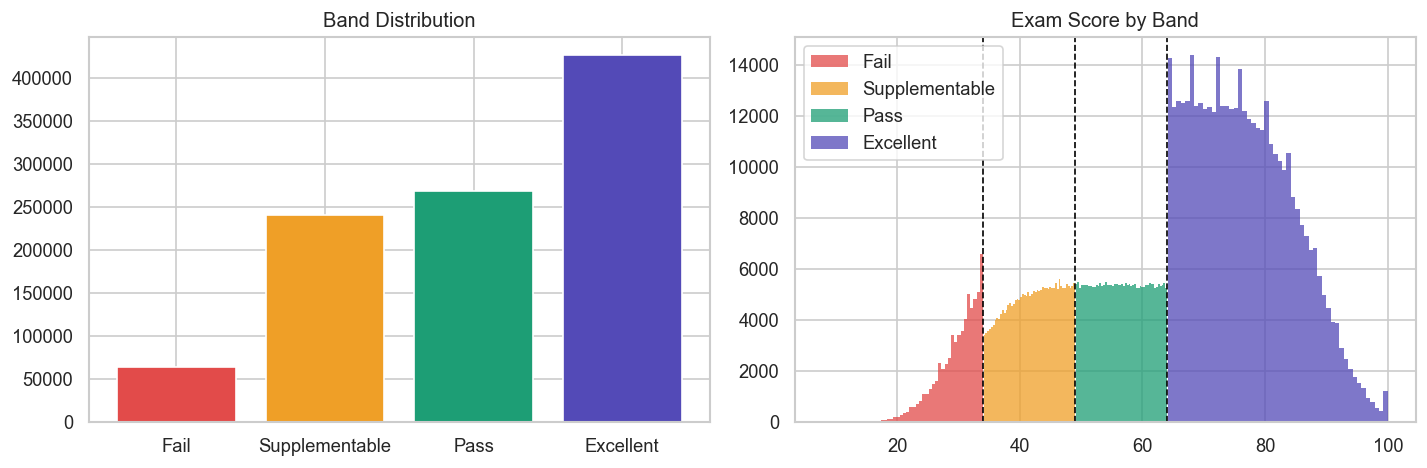

In [5]:
print("[2/8] Applying Layer 1 — updated band assignment...")
df["mzuni_band"]     = df["exam_score"].apply(assign_mzuni_band)
df["mzuni_band_int"] = df["mzuni_band"].map(BAND_TO_INT)

band_counts = df["mzuni_band"].value_counts().reindex(BAND_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(BAND_ORDER, band_counts.values, color=[PALETTE[b] for b in BAND_ORDER], edgecolor="white")
axes[0].set_title("Band Distribution")

for band in BAND_ORDER:
    subset = df[df["mzuni_band"] == band]["exam_score"]
    axes[1].hist(subset, bins=50, alpha=0.75, label=band, color=PALETTE[band], edgecolor="none")
for thresh in [34, 49, 64]:
    axes[1].axvline(thresh, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Exam Score by Band")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}01_band_distribution.png", bbox_inches="tight")
plt.show() # Renders the plot right here!

[3/8] Engineering features...


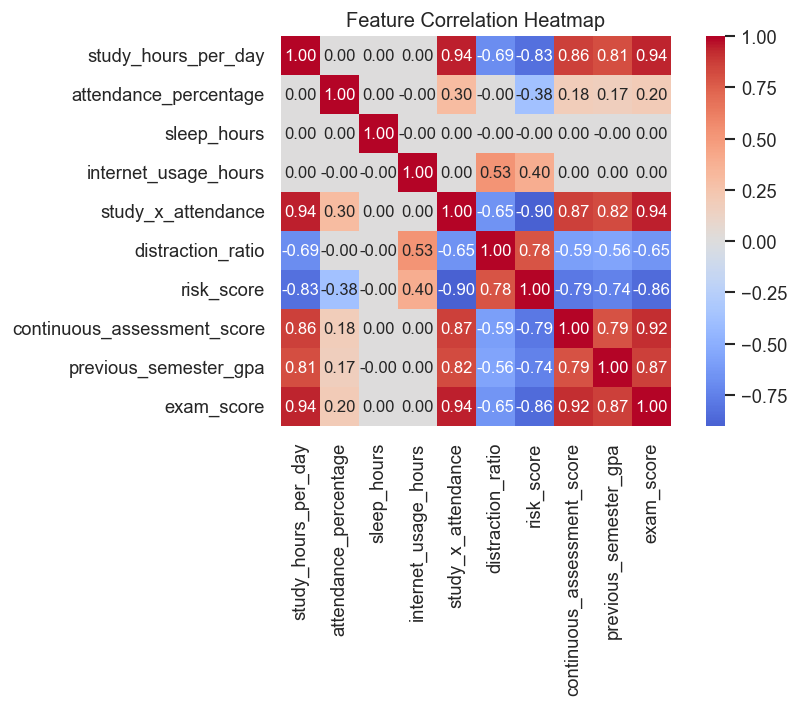

In [6]:
print("[3/8] Engineering features...")
RAW_BEHAV = ["study_hours_per_day", "attendance_percentage", "sleep_hours", "internet_usage_hours"]

df["study_x_attendance"] = df["study_hours_per_day"] * df["attendance_percentage"] / 100
df["distraction_ratio"] = (df["internet_usage_hours"] / (df["study_hours_per_day"] + 0.1)).clip(upper=10)

FEAT_MAXES = {
    "study_hours_per_day":  float(df["study_hours_per_day"].max()),
    "internet_usage_hours": float(df["internet_usage_hours"].max()),
}
study_norm    = df["study_hours_per_day"]   / FEAT_MAXES["study_hours_per_day"]
attend_norm   = df["attendance_percentage"] / 100
internet_norm = df["internet_usage_hours"]  / FEAT_MAXES["internet_usage_hours"]
df["risk_score"] = ((1 - study_norm) * 0.4 + (1 - attend_norm) * 0.4 + internet_norm * 0.2)

ENGINEERED     = ["study_x_attendance", "distraction_ratio", "risk_score"]
NEW_ACADEMIC = ["continuous_assessment_score", "previous_semester_gpa"]
BEHAV_FEATURES = RAW_BEHAV + ENGINEERED + NEW_ACADEMIC
ALL_FEATURES   = BEHAV_FEATURES + ["exam_score"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[ALL_FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

[5/8 & 6/8] Splitting data and training Full Model...
--- Full Model Classification Report ---
                precision    recall  f1-score   support

          Fail       1.00      1.00      1.00     12850
Supplementable       1.00      1.00      1.00     48109
          Pass       1.00      1.00      1.00     53724
     Excellent       1.00      1.00      1.00     85317

      accuracy                           1.00    200000
     macro avg       1.00      1.00      1.00    200000
  weighted avg       1.00      1.00      1.00    200000



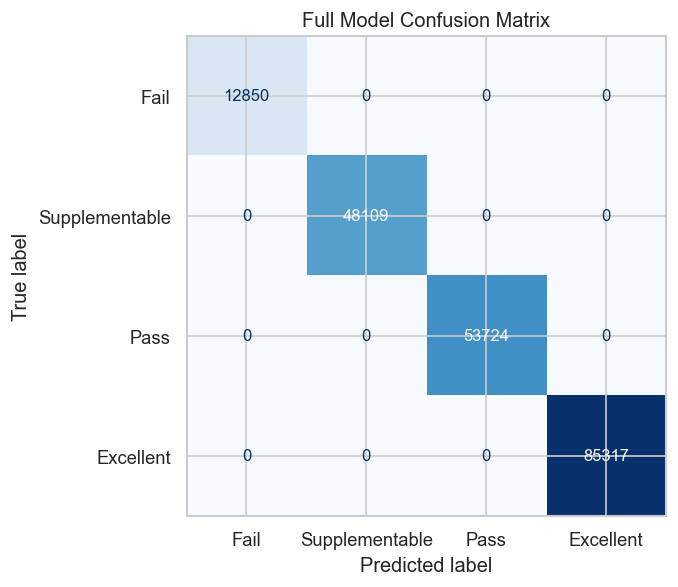

In [7]:
print("[5/8 & 6/8] Splitting data and training Full Model...")
y = df["mzuni_band_int"]
X_all_tr, X_all_te, y_train, y_test = train_test_split(df[ALL_FEATURES], y, test_size=0.2, random_state=42, stratify=y)

rf_full = RandomForestClassifier(
    n_estimators=250,
    max_depth=30,
    min_samples_leaf=1,
    max_features=None,
    criterion="entropy",
    random_state=42, 
    n_jobs=2, 
    class_weight="balanced"
)
rf_full.fit(X_all_tr, y_train)
y_pred_full = rf_full.predict(X_all_te)

print("--- Full Model Classification Report ---")
print(classification_report(y_test, y_pred_full, target_names=BAND_ORDER))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_full), display_labels=BAND_ORDER).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Full Model Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}03a_confusion_full.png", bbox_inches="tight")
plt.show()

# training model apapa elder

[7/8] Training Behavioural model (Aggressive Tuning)...
--- Behavioural Model Metrics ---


,Metric,Score
0,Accuracy,0.8496
1,F1 Score (Macro),0.8064
2,RMSE (Ordinal),0.3879


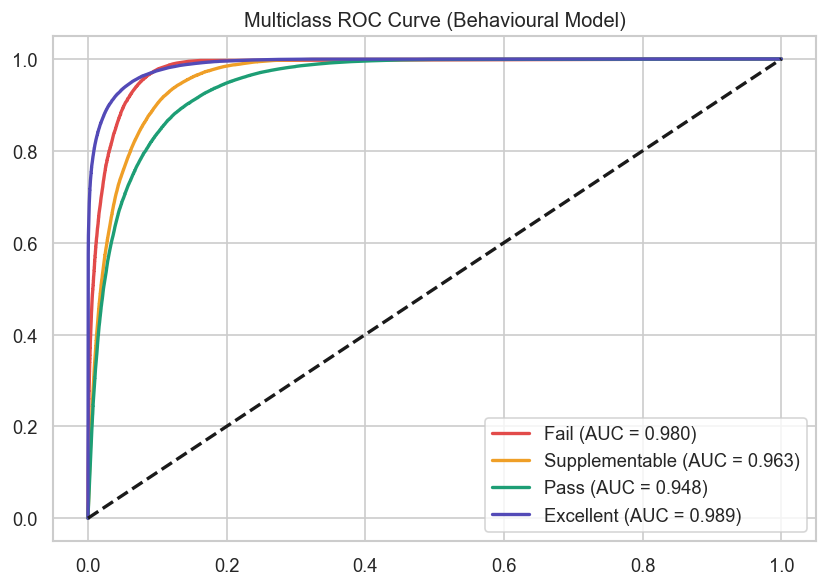

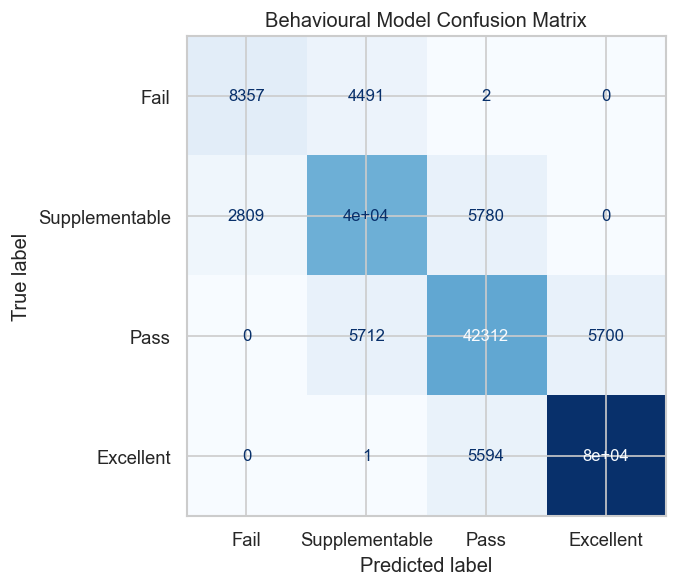

In [8]:
print("[7/8] Training Behavioural model (Aggressive Tuning)...")
X_beh_tr = df[BEHAV_FEATURES].loc[X_all_tr.index]
X_beh_te = df[BEHAV_FEATURES].loc[X_all_te.index]

# Aggressive tuning for maximum accuracy while remaining memory-safe
rf_behav_final = RandomForestClassifier(
    n_estimators=250,       
    max_depth=30,           
    min_samples_leaf=1,     
    max_features=None,      
    criterion="entropy",    
    random_state=42, 
    n_jobs=2,               
    class_weight="balanced"
)
rf_behav_final.fit(X_beh_tr, y_train)

y_pred_final = rf_behav_final.predict(X_beh_te)
y_prob_final = rf_behav_final.predict_proba(X_beh_te)

print("--- Behavioural Model Metrics ---")
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average="macro")
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score (Macro)", "RMSE (Ordinal)"],
    "Score": [round(acc_final, 4), round(f1_final, 4), round(rmse_final, 4)]
})
display(metrics_df)

# ROC Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
fig, ax = plt.subplots(figsize=(7, 5))
colors = [PALETTE[b] for b in BAND_ORDER]

for i, color, band in zip(range(4), colors, BAND_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_final[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{band} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_title('Multiclass ROC Curve (Behavioural Model)')
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}03c_roc_curve_behav.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final), display_labels=BAND_ORDER).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Behavioural Model Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}03b_confusion_behav.png", bbox_inches="tight")
plt.show()

[8/8] Running SHAP explainability...


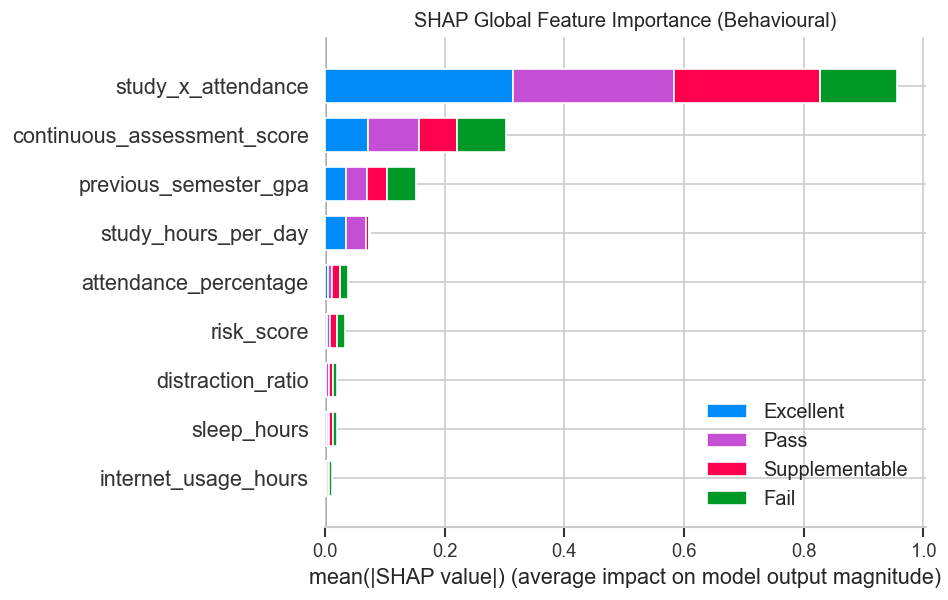

In [9]:
print("[8/8] Running SHAP explainability...")
# Sampling 1000 records so the notebook doesn't freeze while plotting
shap_sample = X_beh_te.sample(1000, random_state=42) 
exp_behav = shap.TreeExplainer(rf_behav_final)

sv_behav = np.array(exp_behav.shap_values(shap_sample))
if sv_behav.ndim == 3 and sv_behav.shape[0] == 4:
    sv_behav = sv_behav.transpose(1, 2, 0)

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_behav, shap_sample, class_names=BAND_ORDER, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Behavioural)")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}04a_shap_global.png", bbox_inches="tight")
plt.show()